# 02 – MC Agent Experiment

**Flow:**
1. Setup & load data
2. Phase 1 – Train MC Agent trên train stream (batch 0-363, 70%)
3. Warm-up – Retrain tất cả models trên `FULL_WINDOW_BATCHES` batches cuối train stream
4. Phase 2 – Evaluate công bằng trên test stream (batch 364-519, 30%)
   - MC Agent: dùng learned policy, **không update thêm**
   - Static   : không retrain
   - Periodic : retrain mỗi 50 batches
   - Always   : retrain mỗi batch
5. Visualize & so sánh

In [ ]:
#!git clone https://github.com/Briannguyen3106/RL-concept-drift.git
#%cd RL-concept-drift
#!pip install -r requirements.txt

Cloning into 'RL-concept-drift'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 110 (delta 34), reused 98 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 11.43 MiB | 26.30 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/kaggle/working/RL-concept-drift


## 1. Setup

In [2]:
import sys, os
import numpy as np
import pandas as pd
import copy
from collections import deque

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from config import (
    BATCH_SIZE, CATEGORICAL_COLS,
    FULL_WINDOW_BATCHES, PARTIAL_WINDOW_BATCHES,
)
from utils.data_loader import AirlinesDataLoader
from models.LightGBM import LightGBM
from metrics.stream_metrics import StreamMetrics
from environment.drift_env import DriftStreamEnv
from agents.mc_agent import MCAgent
from utils.visualizer import (
    plot_dashboard,
    plot_cumulative_reward,
    plot_action_distribution,
    plot_agent_vs_baselines,
    plot_retrain_events,
)

print('Setup complete!')

Setup complete!


## 2. Load Data

In [3]:
loader = AirlinesDataLoader()
X_train, y_train = loader.get_initial_train_data()

print(f'Initial train size : {len(X_train):,}')
print(f'Total stream       : {loader.n_batches} batches')
print(f'Train stream       : {loader.n_train_batches} batches  (batch 0 – {loader.n_train_batches-1})')
print(f'Test  stream       : {loader.n_test_batches} batches  (batch {loader.n_train_batches} – {loader.n_batches-1})')
print(f'Warm-up window     : {FULL_WINDOW_BATCHES} batches  (cuối train stream)')

[DataLoader] Loading data from: /kaggle/working/RL-concept-drift/data/Airlines.csv
[DataLoader] Raw shape: (539383, 9)
[DataLoader] 'Airline' → category dtype (18 unique values)
[DataLoader] 'AirportFrom' → category dtype (293 unique values)
[DataLoader] 'AirportTo' → category dtype (293 unique values)
[DataLoader] Initial train size : 20,000
[DataLoader] Stream size        : 519,383
[DataLoader] Class distribution (train) – 0: 11,529 | 1: 8,471
[DataLoader] Stream split → Train: 363 batches | Test: 156 batches
Initial train size : 20,000
Total stream       : 519 batches
Train stream       : 363 batches  (batch 0 – 362)
Test  stream       : 156 batches  (batch 363 – 518)
Warm-up window     : 10 batches  (cuối train stream)


## 3. Phase 1 – Train MC Agent

Agent được train **chỉ trên train stream** (70% đầu).  
`env.reset(mode="train")` → `stream_train_batches()` → batch 0 đến {n_train-1}.

Baselines **không chạy ở phase này** – chúng sẽ được so sánh ở phase 2.

In [4]:
clf     = LightGBM()
metrics = StreamMetrics()
env     = DriftStreamEnv(loader, clf, metrics)
agent   = MCAgent()

N_TRAIN_EPISODES = 200    # Tăng/giảm tuỳ thời gian chạy

# train() trong BaseAgent tự rotate start_batch theo MC_EPISODE_STARTS
# reset() mặc định mode="train" → stream_train_batches()
training_history = agent.train(env, n_episodes=N_TRAIN_EPISODES, verbose=True)

print(f'\nStates visited      : {len(agent.Q)}')
print(f'Preferences learned : {len(agent.H)}')
print(f'Final temperature   : {agent.temp:.4f}')


Training MCAgent for 200 episodes
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    1/200 | Reward:   200.65 | Avg(10):   200.65 | Steps:  364
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    2/200 | Reward:   158.10 | Avg(10):   179.38 | Steps:  292
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    3/200 | Reward:   119.92 | Avg(10):   159.56 | Steps:  219
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    4/200 | Reward:    82.26 | Avg(10):   140.23 | Steps:  146
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    5/200 | Reward:    37.33 | Avg(10):   119.65 | Steps:   73
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    6/200 | Reward:   198.53 | Avg(10):   132.80 | Steps:  364
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    7/200 | R

In [5]:
agent.save(os.path.join(PROJECT_ROOT,'RL-concept-drift', 'experiments', 'results', 'mc_agent.pkl'))


[MCAgent] Saved → /kaggle/working/RL-concept-drift/experiments/results/mc_agent.pkl


## 4. Learning Curve (Training Phase)

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/mc_learning_curve.png


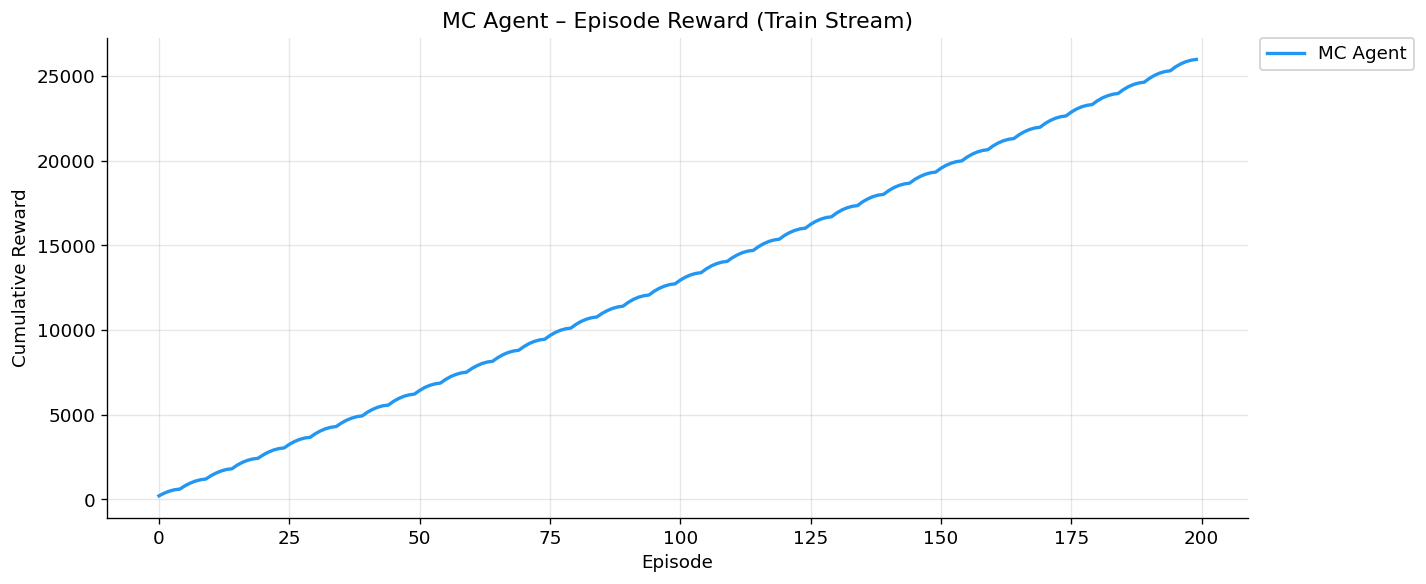

Episodes           : 200
Avg reward (all)   : 129.9156
Avg reward (last10): 134.4494
Best episode       : 228.1650


In [6]:
plot_cumulative_reward(
    {'MC Agent': training_history['episode_rewards']},
    title    = 'MC Agent – Episode Reward (Train Stream)',
    filename = 'mc_learning_curve.png',
)

# Quick stats
rewards = training_history['episode_rewards']
print(f'Episodes           : {len(rewards)}')
print(f'Avg reward (all)   : {np.mean(rewards):.4f}')
print(f'Avg reward (last10): {np.mean(rewards[-10:]):.4f}')
print(f'Best episode       : {max(rewards):.4f}')

## 5. Warm-up – Căn chỉnh tất cả Models trước khi Evaluate

Trước khi vào test stream, ta retrain **tất cả models** ( Static clf, Periodic clf, Always clf)
trên `FULL_WINDOW_BATCHES` batches cuối của train stream.

**Lý do:** Đây là điểm khởi đầu công bằng – tất cả strategies bắt đầu test stream
với model được train trên cùng một đoạn data gần nhất.

In [ ]:
# Lấy FULL_WINDOW_BATCHES batches cuối train stream
X_warm, y_warm = loader.get_warmup_data(n_batches=FULL_WINDOW_BATCHES)
print(f'Warm-up data shape : {X_warm.shape}')
print(f'({FULL_WINDOW_BATCHES} batches × {BATCH_SIZE} samples = {FULL_WINDOW_BATCHES*BATCH_SIZE:,} samples)')

# Warm-up tất cả classifiers
def warmup_clf(name: str) -> LightGBM:
    """Tạo fresh clf, train thẳng trên X_warm (FULL_WINDOW_BATCHES batches cuối train stream)."""
    warmed = LightGBM()
    warmed.full_retrain(X_warm, y_warm)
    print(f'  [{name}] Warmed up on {len(X_warm):,} samples')
    return warmed

# MC Agent clf (đang là state sau episode cuối của training)
# → retrain lại trên warm-up để đồng bộ với baselines
print('Warming up all classifiers...')
clf_static        = warmup_clf('Static')
clf_periodic      = warmup_clf('Periodic')
clf_always        = warmup_clf('Always')
clf_warmed_mc     = warmup_clf('MC Agent')

print('\nAll models warmed up. Ready to evaluate on test stream.')

Warm-up data shape : (10000, 7)
(10 batches × 1000 samples = 10,000 samples)

Warming up all classifiers...
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
  [Static] Warmed up on 10,000 samples
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
  [Periodic] Warmed up on 10,000 samples
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
  [Always] Warmed up on 10,000 samples

All models warmed up. Ready to evaluate on test stream.


## 6. Phase 2 – Evaluate trên Test Stream

### 6a. MC Agent (Learned Policy)

`env.reset(mode="test")` → `stream_test_batches()` → batch {n_train} đến {n_total-1}.  
Agent dùng learned policy, **không gọi `agent.update()`**, không decay epsilon.

In [8]:
def evaluate_mc_agent(agent: MCAgent, env: DriftStreamEnv, n_episodes: int = 3, warm_model = None) -> dict:
    """
    Prequential evaluation của MC Agent trên test stream.

    - mode='test' → stream_test_batches(), không skip, không decay epsilon
    - Agent act theo learned policy (temperature đã decay về MC_TEMP_END)
    - KHÔNG update H, G_bar (no learning)
    - n_episodes > 1 để average qua stochasticity của policy
    """
    print(f'\n=== Evaluating MC Agent on TEST stream ({n_episodes} episodes) ===')

    all_preq_acc    = []
    all_rolling_err = []
    all_drift       = []
    all_uncertainty = []
    all_rewards     = []
    all_actions     = []
    all_retrain_events  = []

    for ep in range(n_episodes):
        # mode='test' → stream_test_batches, không decay epsilon
        state     = env.reset(start_batch=0, mode='test', warm_model=warm_model)
        ep_reward = 0.0
        step      = 0
        ep_retrain_events = []
        ep_actions = []

        while not env.is_done:
            action, pi = agent.select_action(state)

            # update_explorer=False: không update GradientBandit
            next_state, reward, done, info = env.step(
                action,current_state=state, pi=pi, update_explorer=False
            )

            if done and 'action_taken' not in info:
                break

            ep_reward += reward
            ep_actions.append(info['action_taken'])

            if info['action_taken'] in ['partial_update', 'full_retrain']:
                ep_retrain_events.append(info['batch_idx'])

            step  += 1
            state  = next_state
        all_retrain_events.append(ep_retrain_events)
        all_actions.append(ep_actions)

        all_rewards.append(ep_reward)
        all_preq_acc.append(env.metrics.prequential_acc_history.copy())
        all_rolling_err.append(env.metrics.rolling_error_history.copy())
        all_drift.append(env.metrics.drift_measure_history.copy())
        all_uncertainty.append(env.metrics.uncertainty_history.copy())
        print(f'  Episode {ep+1}: reward={ep_reward:.2f}, steps={step}')
    retrain_events = all_retrain_events[-1]

    # Average qua các episodes
    min_len         = min(len(h) for h in all_preq_acc)
    avg_preq_acc    = np.mean([h[:min_len] for h in all_preq_acc],    axis=0).tolist()
    avg_rolling_err = np.mean([h[:min_len] for h in all_rolling_err], axis=0).tolist()
    avg_drift       = np.mean([h[:min_len] for h in all_drift],       axis=0).tolist()
    avg_uncertainty = np.mean([h[:min_len] for h in all_uncertainty], axis=0).tolist()

    action_dist = {}
    action_dist = {}
    for ep_actions in all_actions:
        for a in ep_actions:
            action_dist[a] = action_dist.get(a, 0) + 1
    for k in action_dist:
        action_dist[k] = round(action_dist[k] / n_episodes, 1)

    print(f'\n  Avg reward     : {np.mean(all_rewards):.4f} ± {np.std(all_rewards):.4f}')
    print(f'  Final preq acc : {avg_preq_acc[-1]:.4f}')
    print(f'  Final roll err : {avg_rolling_err[-1]:.4f}')
    print(f'  Action dist    : {action_dist}')
    print(f'  Retrain events : {len(retrain_events)}')

    return {
        'label'          : 'MC Agent',
        'prequential_acc': avg_preq_acc,
        'rolling_error'  : avg_rolling_err,
        'drift_measure'  : avg_drift,
        'uncertainty'    : avg_uncertainty,
        'episode_rewards': all_rewards,
        'action_dist'    : action_dist,
        'retrain_events' : retrain_events,
        'avg_retrains'   : np.mean([len(e) for e in all_retrain_events]),
        'final_summary'  : {
            'prequential_accuracy': avg_preq_acc[-1],
            'rolling_error'       : avg_rolling_err[-1],
            'n_retrains'          : len(retrain_events),
        },
    }
clf_warmed_mc = warmup_clf(env.clf, X_warm, y_warm, 'MC_agent')
results_mc = evaluate_mc_agent(agent, env, n_episodes=3, warm_model= clf_warmed_mc)

  [MC_agent] Warmed up on 10,000 samples

=== Evaluating MC Agent on TEST stream (3 episodes) ===
  Episode 1: reward=95.32, steps=157
  Episode 2: reward=93.23, steps=157
  Episode 3: reward=95.96, steps=157

  Avg reward     : 94.8377 ± 1.1642
  Final preq acc : 0.6260
  Final roll err : 0.4180
  Action dist    : {'partial_update': 5.3, 'alert': 74.7, 'no_action': 66.3, 'full_retrain': 5.7, 'switch_model': 5.0}
  Retrain events : 11


### 6b. Baselines trên Test Stream

In [9]:
def run_baseline_test(strategy: str, clf_warmed: LightGBM,
                      retrain_every: int = 50) -> dict:
    """
    Chạy baseline strategy trên TEST stream.

    Args:
        strategy   : 'static' | 'periodic' | 'always'
        clf_warmed : classifier đã được warm-up (cùng data với MC Agent)
        retrain_every: chu kỳ retrain cho periodic (tính theo batch index test stream)
    """
    print(f'\n=== Baseline: {strategy.upper()} (test stream) ===')

    clf            = copy.deepcopy(clf_warmed)
    metrics        = StreamMetrics()
    window_buffer  = deque(maxlen=FULL_WINDOW_BATCHES)
    retrain_events = []

    # Set reference từ warm-up data
    fold_size   = len(X_warm) // 5
    init_errors = [
        clf.get_error_rate(
            X_warm.iloc[i*fold_size:(i+1)*fold_size],
            y_warm.iloc[i*fold_size:(i+1)*fold_size]
        ) for i in range(5)
    ]
    metrics.set_reference(init_errors)

    batch_count = 0   # local counter trong test stream

    for X_batch, y_batch, idx in loader.stream_test_batches():
        window_buffer.append((X_batch, y_batch))

        preds      = clf.predict(X_batch)
        y_proba    = clf.predict_proba(X_batch)
        error_rate = clf.get_error_rate(X_batch, y_batch)
        metrics.update(y_batch.values, preds, error_rate, y_proba)


        if strategy == 'periodic' and batch_count > 0 and batch_count % retrain_every == 0:
            recent = list(window_buffer)
            X_w = pd.concat([b[0] for b in recent], ignore_index=True)
            y_w = pd.concat([b[1] for b in recent], ignore_index=True)
            for col in CATEGORICAL_COLS:
                X_w[col] = X_w[col].astype('category')
            clf.full_retrain(X_w, y_w)
            retrain_events.append(idx)

        elif strategy == 'always':
            recent = list(window_buffer)
            X_w = pd.concat([b[0] for b in recent], ignore_index=True)
            y_w = pd.concat([b[1] for b in recent], ignore_index=True)
            for col in CATEGORICAL_COLS:
                X_w[col] = X_w[col].astype('category')
            clf.full_retrain(X_w, y_w)
            retrain_events.append(idx)

        
        batch_count += 1

    print(f'  Done! Batches: {batch_count}, Retrains: {len(retrain_events)}')
    return {
        'label'          : strategy,
        'prequential_acc': metrics.prequential_acc_history,
        'rolling_error'  : metrics.rolling_error_history,
        'drift_measure'  : metrics.drift_measure_history,
        'uncertainty'    : metrics.uncertainty_history,
        'retrain_events' : retrain_events,
        'final_summary'  : metrics.summary(),
    }

results_static   = run_baseline_test('static',   clf_static)
results_periodic = run_baseline_test('periodic', clf_periodic, retrain_every=50)
results_always   = run_baseline_test('always',   clf_always)


=== Baseline: STATIC (test stream) ===
  Done! Batches: 156, Retrains: 0

=== Baseline: PERIODIC (test stream) ===
  Done! Batches: 156, Retrains: 3

=== Baseline: ALWAYS (test stream) ===
  Done! Batches: 156, Retrains: 156


## 7. Summary Table

In [10]:
print('\n' + '='*70)
print(f"{'Strategy':<20} {'Preq Acc':>10} {'Roll Err':>10} {'Retrains':>10}")
print('='*70)

for name, results in [
    ('Static',   results_static),
    ('Periodic', results_periodic),
    ('Always',   results_always),
    ('MC Agent', results_mc),
]:
    preq = results['prequential_acc'][-1]
    err  = results['rolling_error'][-1]
    if name == 'MC Agent':
        n_rt = round(results['avg_retrains'])
    else:
        n_rt = len(results['retrain_events'])
    marker = ' ←' if name == 'MC Agent' else ''
    print(f"{name:<20} {preq:>10.4f} {err:>10.4f} {n_rt:>10}{marker}")

print('='*70)
print('* Tất cả strategies evaluate trên test stream (30% cuối).')
print(f'* Warm-up: {FULL_WINDOW_BATCHES} batches cuối train stream (điểm khởi đầu công bằng).')


Strategy               Preq Acc   Roll Err   Retrains
Static                   0.5951     0.3880          0
Periodic                 0.6005     0.3920          3
Always                   0.6710     0.3700        156
MC Agent                 0.6260     0.4180         11 ←
* Tất cả strategies evaluate trên test stream (30% cuối).
* Warm-up: 10 batches cuối train stream (điểm khởi đầu công bằng).


In [11]:
print(results_mc['action_dist'])

{'partial_update': 5.3, 'alert': 74.7, 'no_action': 66.3, 'full_retrain': 5.7, 'switch_model': 5.0}


## 8. Learning Curve (Training Phase)

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/mc_learning_curve.png


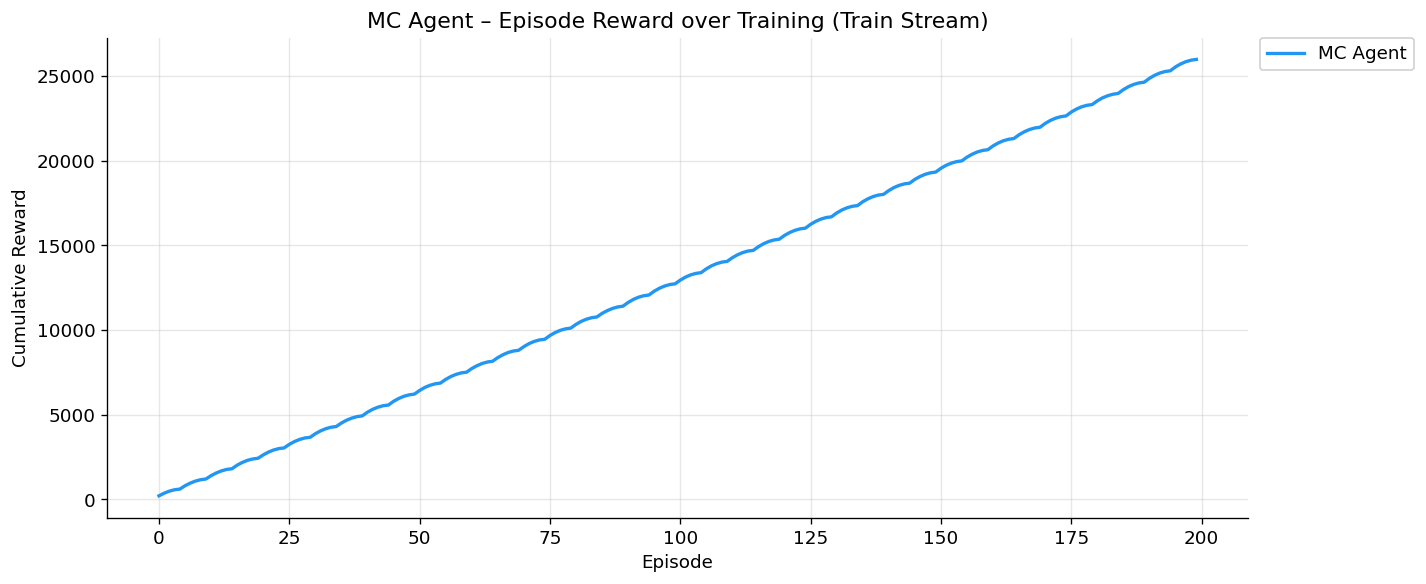

In [12]:
plot_cumulative_reward(
    {'MC Agent': training_history['episode_rewards']},
    title    = 'MC Agent – Episode Reward over Training (Train Stream)',
    filename = 'mc_learning_curve.png',
)

## 9. MC Agent Dashboard (Test Stream)

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/mc_dashboard.png


/kaggle/working/RL-concept-drift/utils/visualizer.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


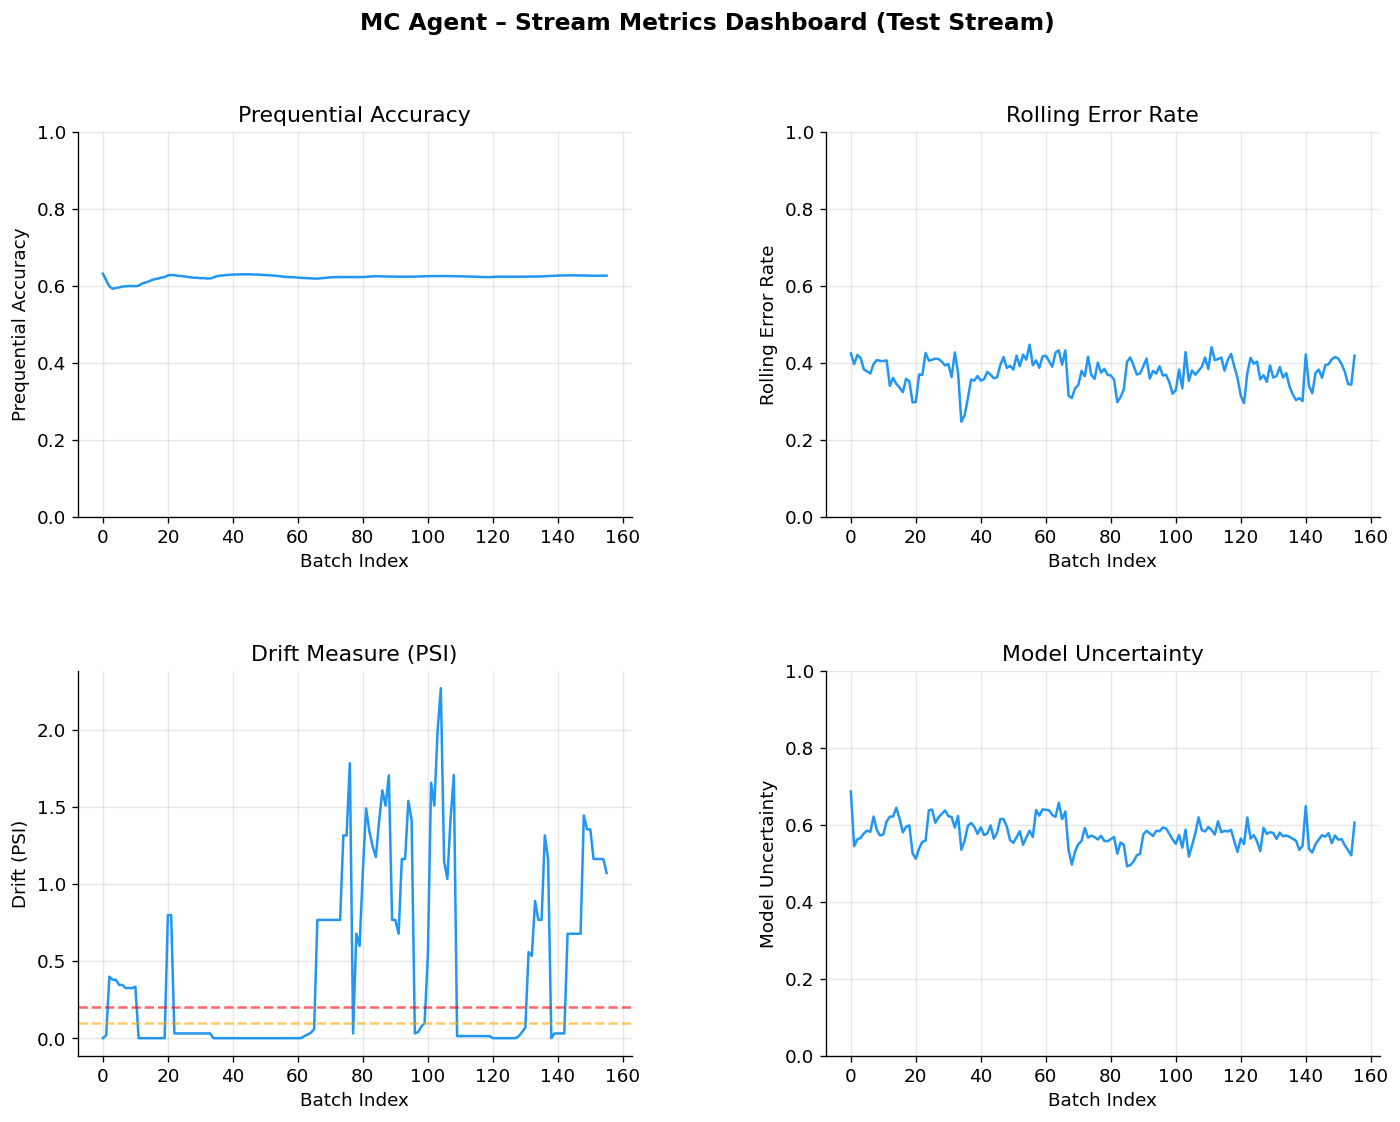

In [13]:
plot_dashboard(
    results_mc,
    title    = 'MC Agent – Stream Metrics Dashboard (Test Stream)',
    filename = 'mc_dashboard.png',
)

## 10. MC Agent vs Baselines (Test Stream)

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/mc_vs_baselines_acc.png


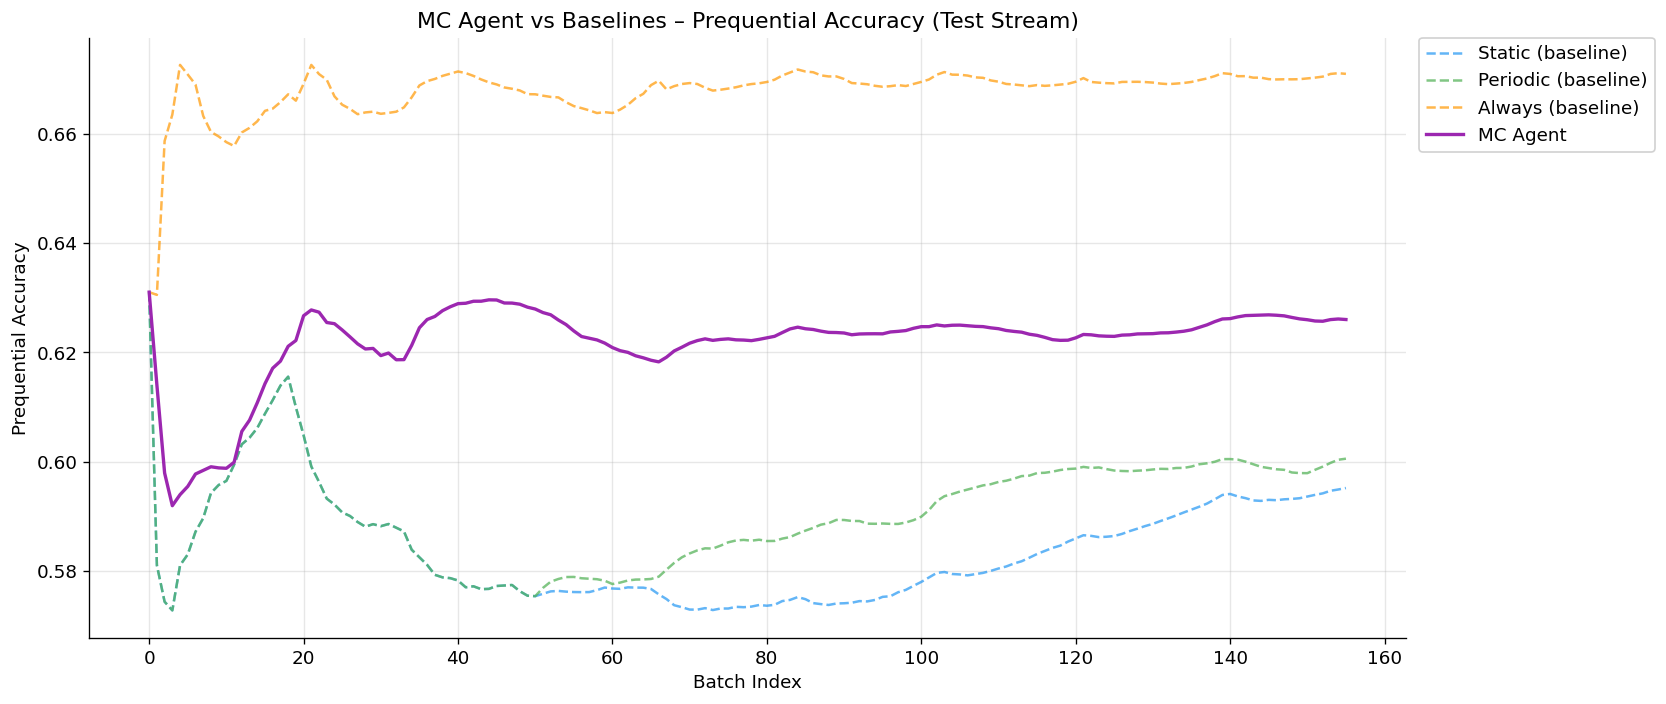

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/mc_vs_baselines_err.png


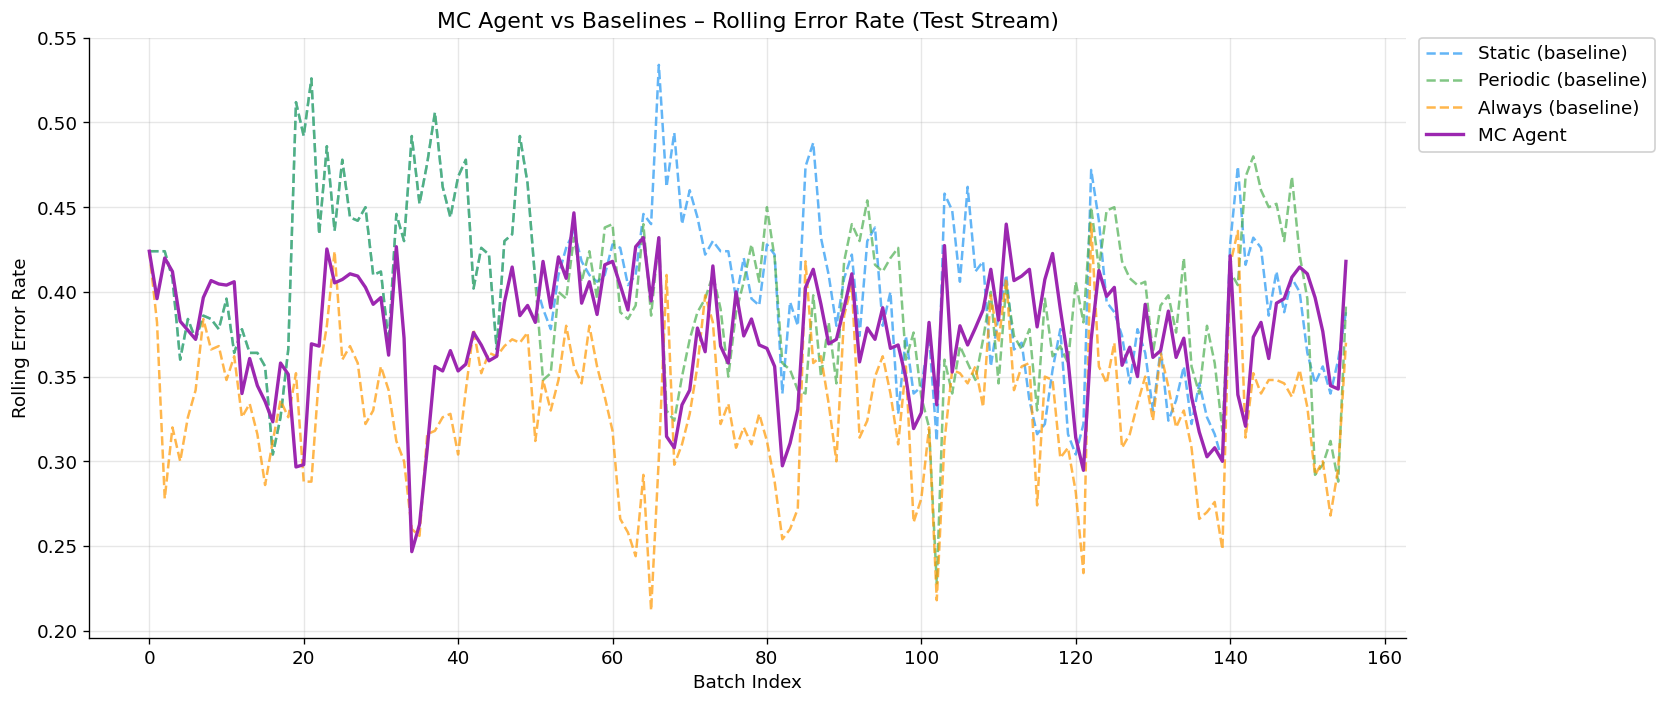

In [14]:
plot_agent_vs_baselines(
    baselines = {
        'Static'  : results_static['prequential_acc'],
        'Periodic': results_periodic['prequential_acc'],
        'Always'  : results_always['prequential_acc'],
    },
    agents   = {'MC Agent': results_mc['prequential_acc']},
    ylabel   = 'Prequential Accuracy',
    title    = 'MC Agent vs Baselines – Prequential Accuracy (Test Stream)',
    filename = 'mc_vs_baselines_acc.png',
)

plot_agent_vs_baselines(
    baselines = {
        'Static'  : results_static['rolling_error'],
        'Periodic': results_periodic['rolling_error'],
        'Always'  : results_always['rolling_error'],
    },
    agents   = {'MC Agent': results_mc['rolling_error']},
    ylabel   = 'Rolling Error Rate',
    title    = 'MC Agent vs Baselines – Rolling Error Rate (Test Stream)',
    filename = 'mc_vs_baselines_err.png',
)

## 11. Action Distribution (Test Stream)

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/mc_action_dist.png


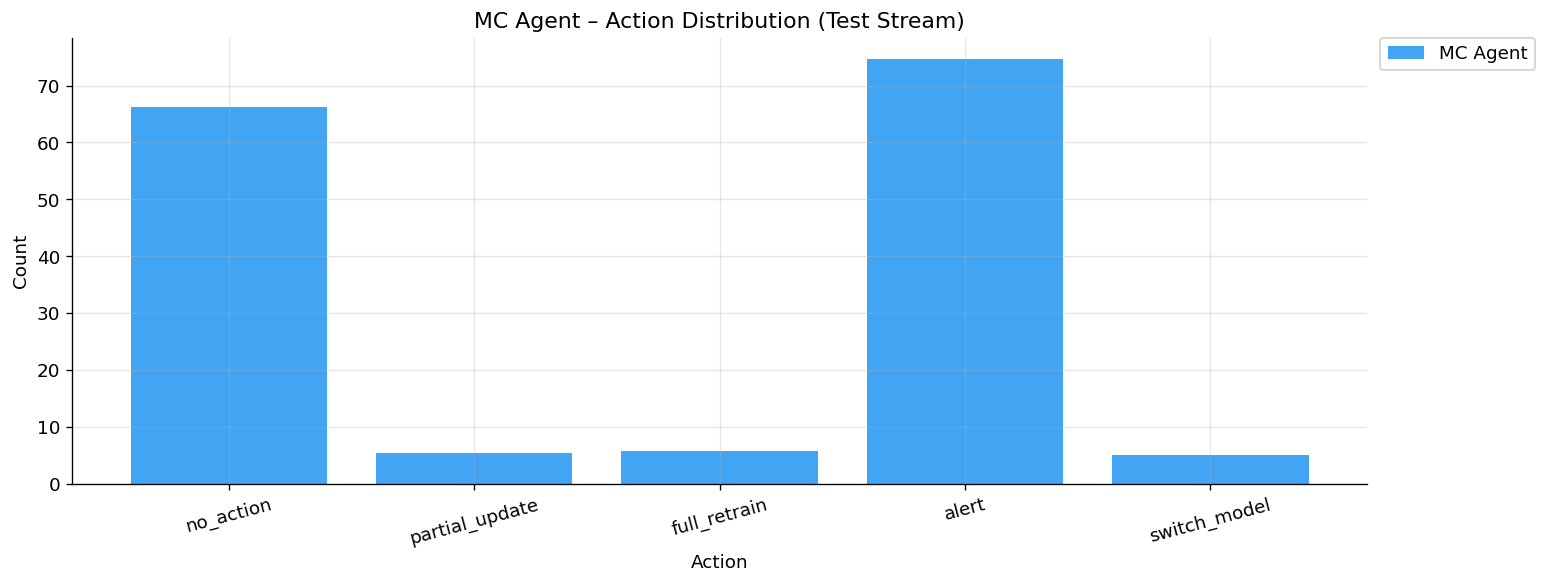


Action counts (test stream, averaged over 3 episodes):
  alert           :  74.7  (47.6%)
  no_action       :  66.3  (42.2%)
  full_retrain    :   5.7  (3.6%)
  partial_update  :   5.3  (3.4%)
  switch_model    :   5.0  (3.2%)


In [15]:
plot_action_distribution(
    {'MC Agent': results_mc['action_dist']},
    title    = 'MC Agent – Action Distribution (Test Stream)',
    filename = 'mc_action_dist.png',
)

print('\nAction counts (test stream, averaged over 3 episodes):')
total = sum(results_mc['action_dist'].values())
for action, count in sorted(results_mc['action_dist'].items(), key=lambda x: -x[1]):
    print(f'  {action:<16}: {count:>5}  ({100*count/total:.1f}%)')

## 12. Retrain Events (Test Stream)

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/mc_retrain_events.png


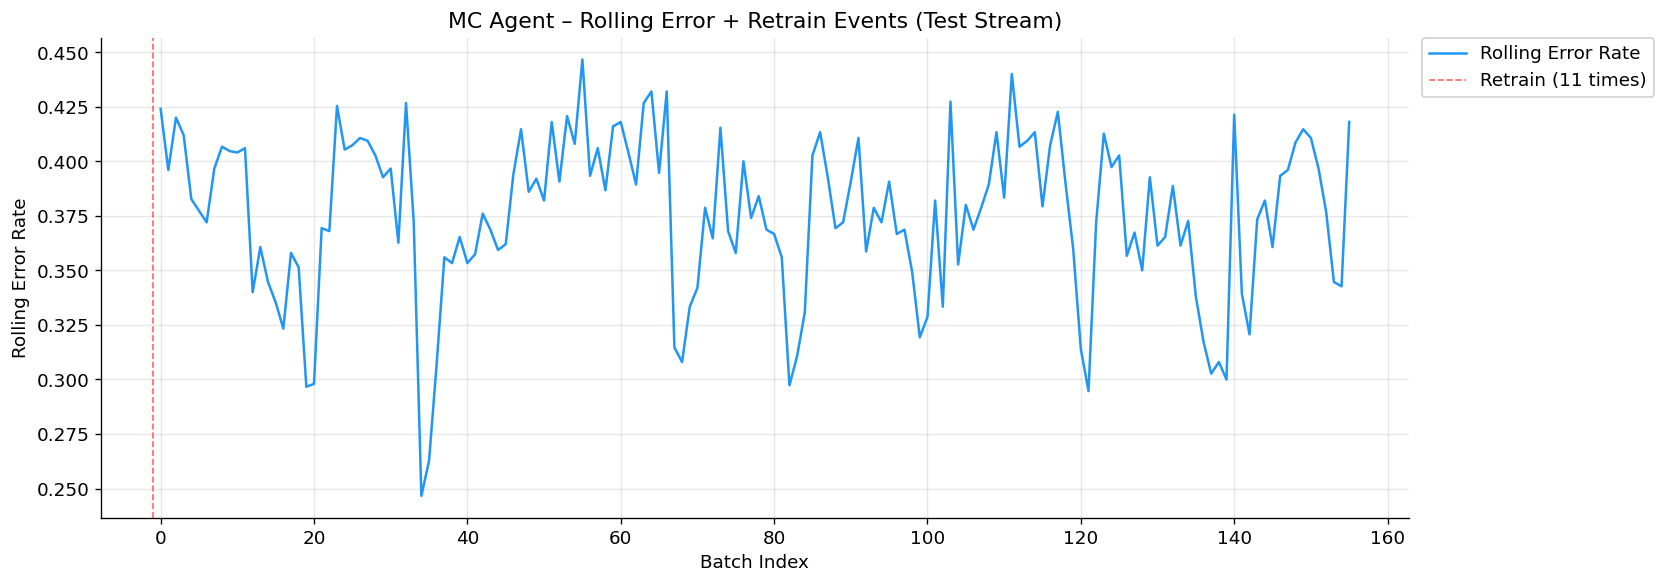

In [16]:
plot_retrain_events(
    results_mc['rolling_error'],
    results_mc['retrain_events'],
    title    = 'MC Agent – Rolling Error + Retrain Events (Test Stream)',
    filename = 'mc_retrain_events.png',
)

## 13. Observations

**Setup:**
- Train stream: batch 0–{n_train-1} ({train_pct}% data stream)
- Test stream : batch {n_train}–{n_total-1} ({test_pct}% data stream)
- Warm-up     : `FULL_WINDOW_BATCHES` batches cuối train stream → điểm khởi đầu công bằng

**Câu hỏi cần trả lời sau khi chạy:**

*Learning curve:*
- Reward có tăng dần qua 200 episodes không?
- Bao nhiêu episodes để bắt đầu hội tụ?
- Temperature decay có ảnh hưởng rõ đến exploration/exploitation không?

*So sánh test stream:*
- MC Agent prequential accuracy vs Static / Periodic / Always?
- MC Agent rolling error thấp hơn Static không?
- Số lần retrain của MC Agent so với Periodic (mỗi 50 batches)?
- MC Agent có efficient hơn Always (ít retrain hơn nhưng accuracy tương đương)?

*Action distribution:*
- Agent có học được khi nào nên retrain không?
- Tỷ lệ `no_action` vs `full_retrain` vs `partial_update`?
- Agent có dùng `alert` và `switch_model` không?

→ Nếu kết quả tốt: tăng lên 500 episodes, giảm temperature decay chậm hơn.  
→ Nếu chưa tốt: kiểm tra reward function, action costs, drift measure (thử đổi PSI → ADWIN).